# CNN-A — El Clásico: MNIST con arquitectura LeNet

**Dataset:** MNIST — 70.000 imágenes 28×28 en escala de grises, dígitos 0–9  
**Arquitectura:** 2 bloques Conv→MaxPool + capas densas finales (estilo LeNet)  
**Augmentación:** ninguna — entrenamiento limpio sobre datos originales  
**Objetivo:** baseline sólido para comparar con CNN-B en la app interactiva

---
## Índice
1. Imports y configuración
2. Carga y exploración del dataset
3. Preprocesamiento
4. Arquitectura del modelo
5. Entrenamiento
6. Evaluación y análisis de errores
7. Guardado del modelo

---
## 1. Imports y configuración

In [13]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white', 'font.size': 11})

print(f'TensorFlow: {tf.__version__}')
print(f'GPU disponible: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow: 2.15.0
GPU disponible: False


---
## 2. Carga y exploración del dataset

In [14]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()

print(f'Train: {X_train_full.shape}  dtype={X_train_full.dtype}')
print(f'Test:  {X_test.shape}')
print(f'Clases: {np.unique(y_train_full)}')
print(f'Rango de píxeles: [{X_train_full.min()}, {X_train_full.max()}]')

Train: (60000, 28, 28)  dtype=uint8
Test:  (10000, 28, 28)
Clases: [0 1 2 3 4 5 6 7 8 9]
Rango de píxeles: [0, 255]


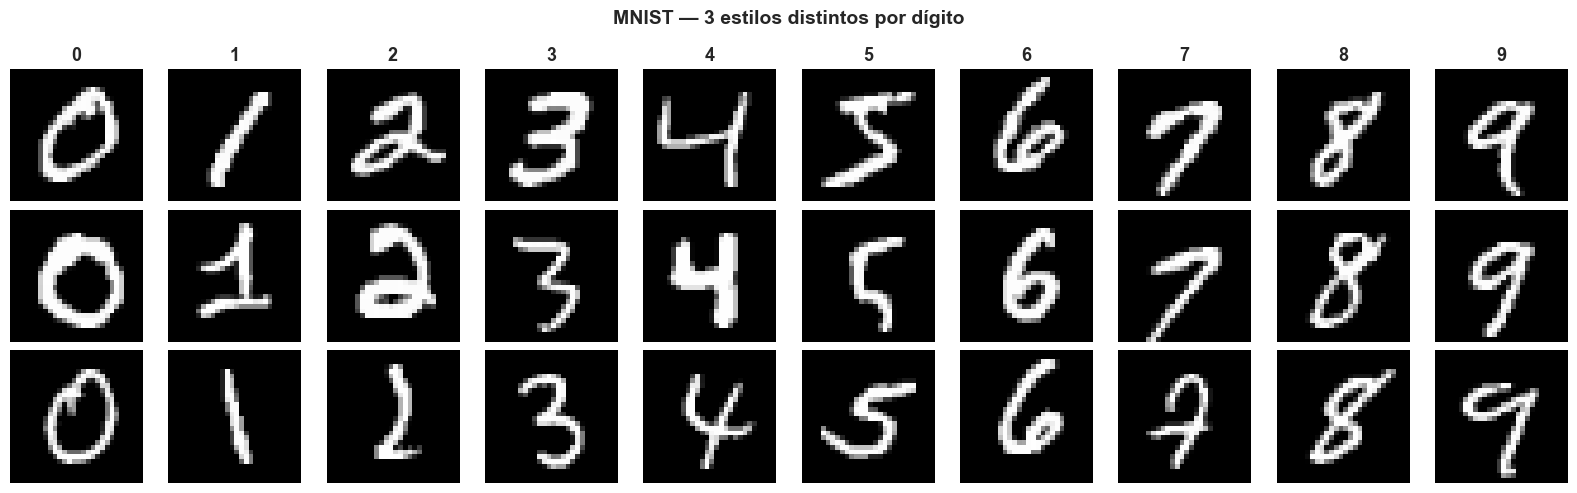

Observa que incluso en MNIST hay variación entre escrituras del mismo dígito.


In [15]:
fig, axes = plt.subplots(3, 10, figsize=(16, 5))

for digit in range(10):
    idxs = np.where(y_train_full == digit)[0]
    for row, sample_idx in enumerate([0, 5, 15]):
        axes[row, digit].imshow(X_train_full[idxs[sample_idx]], cmap='gray')
        axes[row, digit].axis('off')
        if row == 0:
            axes[row, digit].set_title(str(digit), fontsize=13, fontweight='bold')

plt.suptitle('MNIST — 3 estilos distintos por dígito', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('Observa que incluso en MNIST hay variación entre escrituras del mismo dígito.')

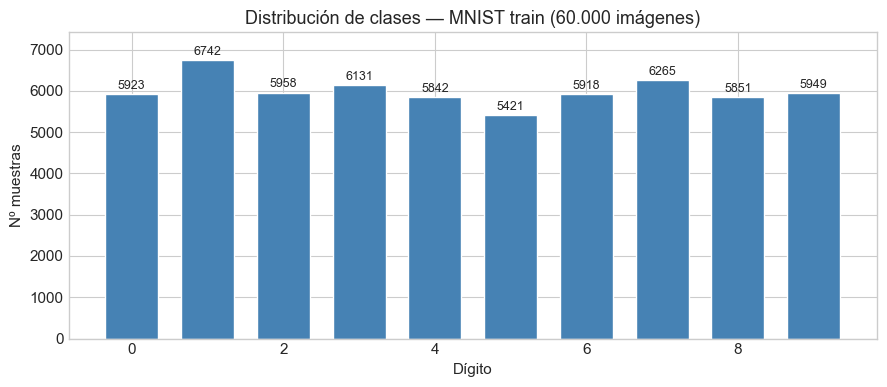

Mínimo: 5421 (5) | Máximo: 6742 (1)
Ratio max/min: 1.24x  → Dataset muy equilibrado, sin desbalance.


In [16]:
unique, counts = np.unique(y_train_full, return_counts=True)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(unique, counts, color='steelblue', edgecolor='white', width=0.7)
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            str(c), ha='center', va='bottom', fontsize=9)
ax.set_title('Distribución de clases — MNIST train (60.000 imágenes)', fontsize=13)
ax.set_xlabel('Dígito')
ax.set_ylabel('Nº muestras')
ax.set_ylim(0, counts.max() * 1.1)
plt.tight_layout()
plt.show()

print(f'Mínimo: {counts.min()} ({unique[counts.argmin()]}) | Máximo: {counts.max()} ({unique[counts.argmax()]})')
print(f'Ratio max/min: {counts.max()/counts.min():.2f}x  → Dataset muy equilibrado, sin desbalance.')

---
## 3. Preprocesamiento

Dos pasos obligatorios antes de meter los datos a una CNN con Keras:
- **Normalizar** los píxeles de [0,255] a [0,1]: ayuda al gradiente a converger más rápido.
- **Añadir la dimensión de canal**: la imagen pasa de (28,28) a (28,28,1). Keras espera esa dimensión extra para saber cuántos canales tiene la imagen (1 = grises, 3 = RGB).

Dividimos en tres conjuntos: **train 70% / val 15% / test 15%**.

In [17]:
X_train_full = X_train_full.astype('float32') / 255.0
X_test       = X_test.astype('float32') / 255.0

X_train_full = X_train_full[..., np.newaxis]  # (60000, 28, 28, 1)
X_test       = X_test[..., np.newaxis]         # (10000, 28, 28, 1)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.1765,
    random_state=SEED,
    stratify=y_train_full
)

print(f'Train: {X_train.shape}   ({len(X_train):,} imgs)')
print(f'Val:   {X_val.shape}   ({len(X_val):,} imgs)')
print(f'Test:  {X_test.shape}   ({len(X_test):,} imgs)')
print(f'Rango tras normalizar: [{X_train.min():.1f}, {X_train.max():.1f}]')

Train: (49410, 28, 28, 1)   (49,410 imgs)
Val:   (10590, 28, 28, 1)   (10,590 imgs)
Test:  (10000, 28, 28, 1)   (10,000 imgs)
Rango tras normalizar: [0.0, 1.0]


---
## 4. Arquitectura del modelo — CNN-A LeNet

```
Input (28×28×1)
  → Conv2D(32, 3×3, relu, padding=same)
  → MaxPooling2D(2×2)          ← imagen: 14×14
  → Conv2D(64, 3×3, relu, padding=same)
  → MaxPooling2D(2×2)          ← imagen: 7×7
  → Flatten                   ← 7×7×64 = 3.136 valores
  → Dense(128, relu)
  → Dropout(0.3)
  → Dense(10, softmax)         ← probabilidad para cada dígito
```

**¿Por qué `sparse_categorical_crossentropy`?**  
Porque las etiquetas son enteros (0,1,...,9), no vectores one-hot. Si fueran one-hot usaríamos `categorical_crossentropy`.

In [18]:
def build_cnn_a():
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),

        # Bloque 1: detecta bordes y texturas simples
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        # Bloque 2: detecta formas más complejas
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        # Clasificador
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ], name='CNN_A_LeNet')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model_a = build_cnn_a()
model_a.summary()

Model: "CNN_A_LeNet"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 28, 28, 32)        320       
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 14, 14, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_3 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 7, 7, 64)          0         
 g2D)                                                            
                                                                 
 flatten_1 (Flatten)         (None, 3136)              0         
                                                                 
 dense_2 (Dense)             (None, 128)               

---
## 5. Entrenamiento

- `EarlyStopping(patience=5)`: si la validación no mejora 5 épocas seguidas, para y restaura el mejor modelo.
- `batch_size=64`: número de imágenes por actualización de pesos.
- `epochs=25`: máximo de vueltas. Early stopping cortará antes si procede.

In [19]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_a = model_a.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/25
773/773 [==============================] - 23s 28ms/step - loss: 0.2021 - accuracy: 0.9369 - val_loss: 0.0668 - val_accuracy: 0.9805
Epoch 2/25
773/773 [==============================] - 20s 25ms/step - loss: 0.0679 - accuracy: 0.9796 - val_loss: 0.0500 - val_accuracy: 0.9861
Epoch 3/25
773/773 [==============================] - 21s 27ms/step - loss: 0.0482 - accuracy: 0.9851 - val_loss: 0.0430 - val_accuracy: 0.9881
Epoch 4/25
773/773 [==============================] - 19s 25ms/step - loss: 0.0382 - accuracy: 0.9885 - val_loss: 0.0467 - val_accuracy: 0.9844
Epoch 5/25
773/773 [==============================] - 19s 25ms/step - loss: 0.0297 - accuracy: 0.9905 - val_loss: 0.0381 - val_accuracy: 0.9899
Epoch 6/25
773/773 [==============================] - 19s 25ms/step - loss: 0.0255 - accuracy: 0.9918 - val_loss: 0.0434 - val_accuracy: 0.9892
Epoch 7/25
773/773 [==============================] - 21s 27ms/step - loss: 0.0216 - accuracy: 0.9930 - val_loss: 0.0453 - val_accuracy:

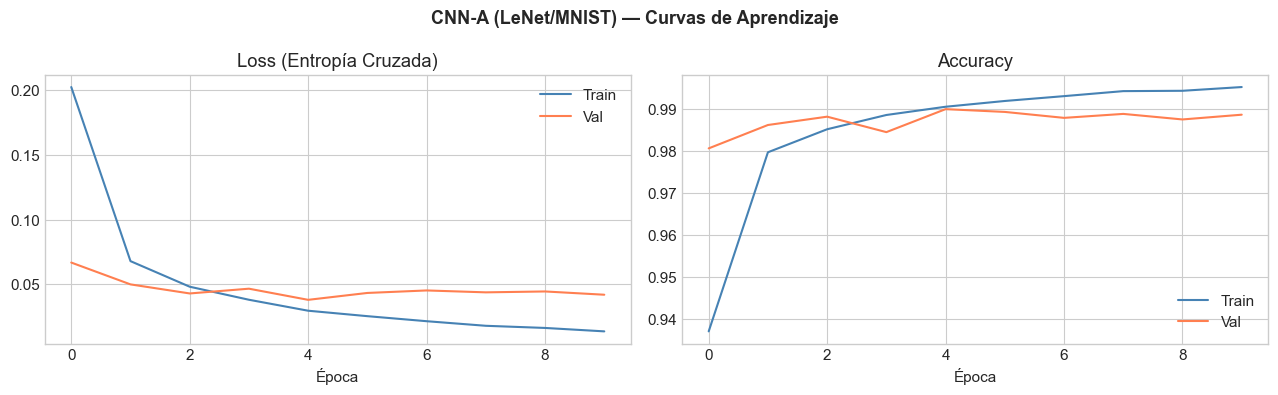

Entrenamiento completado en 10 épocas (Early Stopping activo si < 25)


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history_a.history['loss'],     label='Train', color='steelblue')
axes[0].plot(history_a.history['val_loss'], label='Val',   color='coral')
axes[0].set_title('Loss (Entropía Cruzada)')
axes[0].set_xlabel('Época')
axes[0].legend()

axes[1].plot(history_a.history['accuracy'],     label='Train', color='steelblue')
axes[1].plot(history_a.history['val_accuracy'], label='Val',   color='coral')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Época')
axes[1].legend()

plt.suptitle('CNN-A (LeNet/MNIST) — Curvas de Aprendizaje', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

epocas = len(history_a.history['loss'])
print(f'Entrenamiento completado en {epocas} épocas (Early Stopping activo si < 25)')

---
## 6. Evaluación y análisis de errores

In [21]:
test_loss, test_acc = model_a.evaluate(X_test, y_test, verbose=0)
print(f'Test Loss:     {test_loss:.4f}')
print(f'Test Accuracy: {test_acc*100:.2f}%')
print(f'Test Error:    {(1-test_acc)*100:.2f}%')

y_pred = np.argmax(model_a.predict(X_test, verbose=0), axis=1)
print()
print(classification_report(y_test, y_pred, digits=4))

Test Loss:     0.0267
Test Accuracy: 99.09%
Test Error:    0.91%

              precision    recall  f1-score   support

           0     0.9899    0.9969    0.9934       980
           1     0.9913    0.9991    0.9952      1135
           2     0.9904    0.9961    0.9932      1032
           3     0.9960    0.9891    0.9925      1010
           4     0.9949    0.9929    0.9939       982
           5     0.9759    0.9966    0.9861       892
           6     0.9948    0.9896    0.9922       958
           7     0.9922    0.9883    0.9903      1028
           8     0.9907    0.9825    0.9866       974
           9     0.9920    0.9772    0.9845      1009

    accuracy                         0.9909     10000
   macro avg     0.9908    0.9908    0.9908     10000
weighted avg     0.9909    0.9909    0.9909     10000



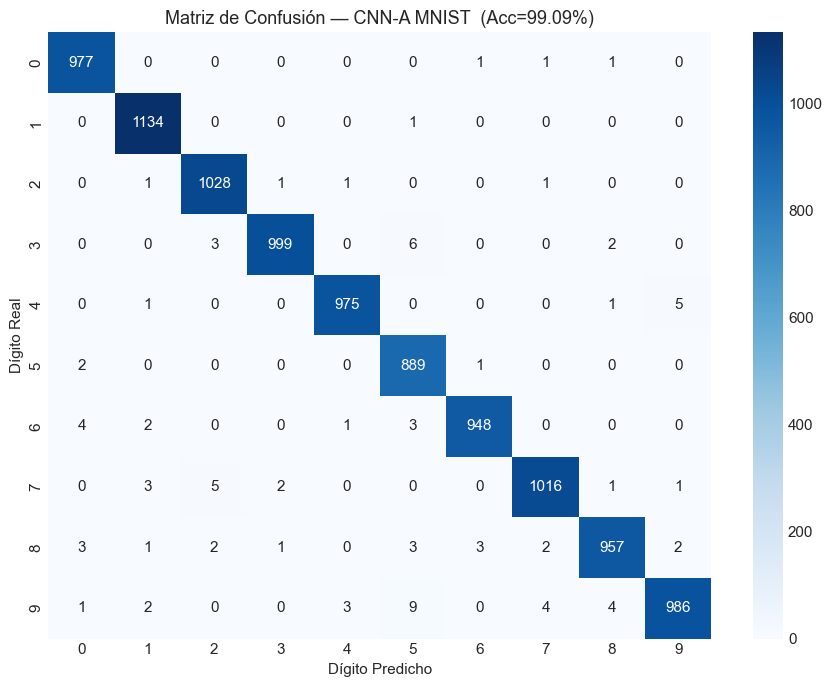

Par más confundido: real=9 predicho como 5 (9 veces)


In [22]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=range(10), yticklabels=range(10))
ax.set_xlabel('Dígito Predicho')
ax.set_ylabel('Dígito Real')
ax.set_title(f'Matriz de Confusión — CNN-A MNIST  (Acc={test_acc*100:.2f}%)', fontsize=13)
plt.tight_layout()
plt.show()

# Dígitos que más se confunden
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
max_err = np.unravel_index(cm_no_diag.argmax(), cm_no_diag.shape)
print(f'Par más confundido: real={max_err[0]} predicho como {max_err[1]} ({cm_no_diag[max_err]} veces)')

Errores totales: 91 de 10000 (0.91%)


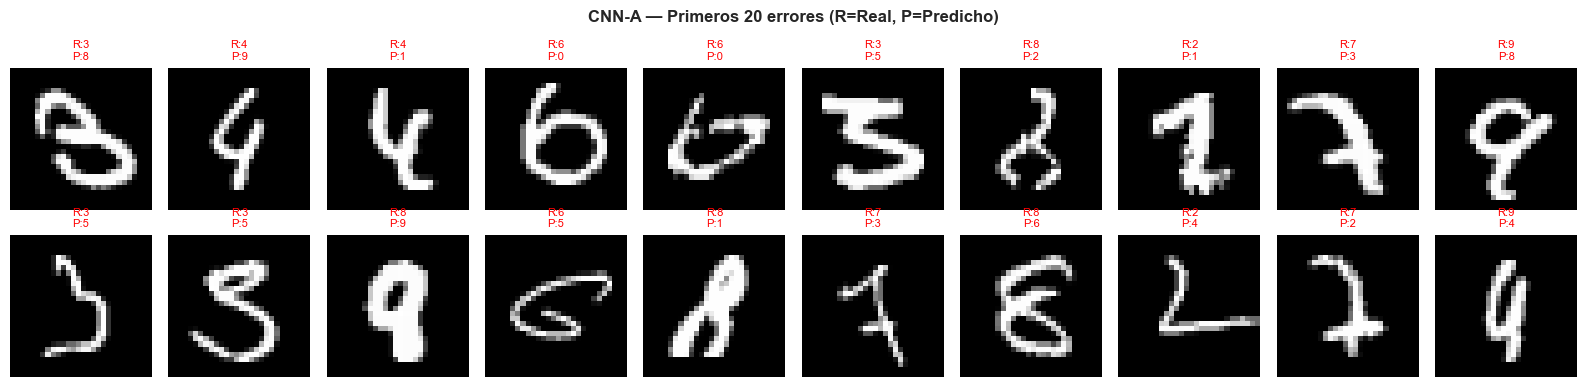

¿Puedes adivinar por qué la red se equivocó en cada caso?


In [23]:
wrong_idx = np.where(y_pred != y_test)[0]
print(f'Errores totales: {len(wrong_idx)} de {len(y_test)} ({len(wrong_idx)/len(y_test)*100:.2f}%)')

n_show = min(20, len(wrong_idx))
fig, axes = plt.subplots(2, 10, figsize=(16, 4))

for i, idx in enumerate(wrong_idx[:n_show]):
    ax = axes[i // 10, i % 10]
    ax.imshow(X_test[idx].squeeze(), cmap='gray')
    ax.set_title(f'R:{y_test[idx]}\nP:{y_pred[idx]}',
                 fontsize=8,
                 color='red' if y_test[idx] != y_pred[idx] else 'green')
    ax.axis('off')

plt.suptitle('CNN-A — Primeros 20 errores (R=Real, P=Predicho)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print('¿Puedes adivinar por qué la red se equivocó en cada caso?')

---
## 7. Guardado del modelo

Se guarda en `../models/cnn_a_mnist.keras` para que la app Streamlit lo cargue.

In [24]:
os.makedirs('../models', exist_ok=True)
model_a.save('../models/cnn_a_mnist.keras')
print('Guardado: ../models/cnn_a_mnist.keras')

# Verificación rápida
loaded = keras.models.load_model('../models/cnn_a_mnist.keras')
_, acc_loaded = loaded.evaluate(X_test, y_test, verbose=0)
print(f'Verificación tras carga: accuracy = {acc_loaded*100:.2f}%')
print()
print('=== RESUMEN CNN-A ===')
print(f'  Dataset:       MNIST (60.000 train + 10.000 test)')
print(f'  Arquitectura:  Conv32 → MaxPool → Conv64 → MaxPool → Dense128 → Dense10')
print(f'  Augmentación:  ninguna')
print(f'  Test Accuracy: {test_acc*100:.2f}%')
print()
print('Siguiente paso: ejecuta cnn_b_emnist.ipynb para entrenar el modelo robusto.')

Guardado: ../models/cnn_a_mnist.keras
Verificación tras carga: accuracy = 99.09%

=== RESUMEN CNN-A ===
  Dataset:       MNIST (60.000 train + 10.000 test)
  Arquitectura:  Conv32 → MaxPool → Conv64 → MaxPool → Dense128 → Dense10
  Augmentación:  ninguna
  Test Accuracy: 99.09%

Siguiente paso: ejecuta cnn_b_emnist.ipynb para entrenar el modelo robusto.
